## Modeling Phase

With the dataset cleaned and prepared, the next step is to build and evaluate classification models to predict wine quality.

Given the class imbalance identified during the exploratory analysis, model evaluation goes beyond standard metrics such as accuracy. Instead, the focus is placed on metrics that better reflect the impact of different types of prediction errors.

In particular, a cost-sensitive approach is adopted, where false positives carry a significantly higher penalty than other types of errors. This makes precision a critical metric in the modeling process.

Additionally, predicted probabilities are used to adjust the classification threshold, allowing model decisions to be aligned with the defined cost structure and business objective of maximizing profit.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score

In [4]:
data = pd.read_csv("wine_clean_data.csv")

### Train-Test Split

Before training the models, the dataset is split into training and testing sets.

A stratified split is used to preserve the original class distribution, ensuring that both sets maintain the imbalance observed during the exploratory analysis. This is critical to obtain reliable and comparable performance metrics.

The target variable is also encoded into a binary format:
- 1 → High quality (Premium)
- 0 → Low quality (Normal)

In [5]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop(columns=['quality', 'quality_label'])
y = data['quality_label']

# Labeling before the division: 'Low' -> 0, 'High' -> 1
y = y.map({'Low': 0, 'High': 1})

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
# Compare class proportions between train and test sets
print("Train Test Split\n")

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

print("\nClass distribution")

summary = pd.DataFrame({
    'Train (%)': (y_train.value_counts(normalize=True)*100).round(2),
    'Test (%)': (y_test.value_counts(normalize=True)*100).round(2)
})

print(summary)

Train Test Split

Train size: (3248, 12)
Test size: (1392, 12)

Class distribution
               Train (%)  Test (%)
quality_label                     
0                  78.33      78.3
1                  21.67      21.7


The results confirm that the stratified split successfully preserved the original class distribution, with approximately 78% Low quality wines and 22% High quality wines in both training and testing sets.

This consistency enables a fair comparison of model performance and is especially important when evaluating models using cost-sensitive metrics such as profit, where class proportions directly influence the final outcome.

## Models

### Logistic Regression

Logistic Regression is used as the first benchmark model in the classification stage.

It provides a strong and interpretable baseline, allowing us to understand how key features influence the probability of a wine being classified as High quality.

While relatively simple, this model serves as a reference point for evaluating whether more complex models can deliver meaningful improvements in performance and business impact.

In [7]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

To improve baseline performance, hyperparameter tuning is applied using GridSearchCV with Stratified K-Fold cross-validation.

Precision is selected as the optimization metric at this stage because false positives carry the highest penalty in the business cost structure. This makes it more important to control incorrect High quality predictions than to maximize overall accuracy.

In [ ]:
# Hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__class_weight': ['balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline_lr,
    param_grid,
    cv=cv,
    scoring='precision',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': ['balanced'],
                         'model__penalty': ['l2']},
             scoring='precision')

In [ ]:
# Extracting fold scores for the best parameter combination
cv_results = grid.cv_results_
best_index = grid.best_index_

fold_scores = [
    cv_results[f'split{i}_test_score'][best_index]
    for i in range(cv.get_n_splits())
]

print("Best params:", grid.best_params_) # Best parameter combination
print("Fold scores:", [f"{score:.4f}" for score in fold_scores]) # Precision scores for each fold
print(f"Best CV Precision: {grid.best_score_:.4f}") # Best precision across all folds for the best parameters
print(f"Mean CV Precision: {cv_results['mean_test_score'][grid.best_index_]:.4f}") # Mean precision across all folds for the best parameters
print(f"Std CV Precision: {cv_results['std_test_score'][grid.best_index_]:.4f}") # Standard deviation of precision across all folds for the best parameters

Best params: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Fold scores: ['0.3793', '0.4280', '0.4173', '0.3846', '0.4120']
Best CV Precision: 0.4043
Mean CV Precision: 0.4043
Std CV Precision: 0.0190


The best-performing configuration achieved a mean cross-validated precision of approximately 0.40, with low variability across folds.

This indicates that the model delivers stable precision performance, although the absolute value suggests there is room for improvement in controlling false positives. This makes Logistic Regression a useful baseline, but not necessarily the optimal solution for the problem.

After selecting the best hyperparameter combination, the model is evaluated on the test set.

Instead of relying only on the default classification threshold, the decision threshold is manually increased to 0.65 in order to make positive predictions more conservative. This adjustment is aligned with the business objective of reducing false positives, which are the most costly type of error in the defined cost matrix.

In [25]:
best_model = grid.best_estimator_

y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

# Increase the decision threshold to reduce false positives
threshold_lr = 0.65
y_pred_lr_mod = (y_proba_lr >= threshold_lr).astype(int)

acc_lr = accuracy_score(y_test, y_pred_lr_mod)
precision_lr = precision_score(y_test, y_pred_lr_mod)
cm_lr = confusion_matrix(y_test, y_pred_lr_mod)
report_lr = classification_report(y_test, y_pred_lr_mod, target_names=['Low', 'High'], digits=4)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression (threshold = {threshold_lr})")
print(f"Accuracy test: {acc_lr:.4f}")
print(f"ROC AUC: {auc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}\n")
print("Classification report:")
print(report_lr)
print("Confusion Matrix:")
print(cm_lr)

Logistic Regression (threshold = 0.65)
Accuracy test: 0.8082
ROC AUC: 0.8123
Precision: 0.5651

Classification report:
              precision    recall  f1-score   support

         Low     0.8664    0.8927    0.8793      1090
        High     0.5651    0.5033    0.5324       302

    accuracy                         0.8082      1392
   macro avg     0.7157    0.6980    0.7059      1392
weighted avg     0.8010    0.8082    0.8041      1392

Confusion Matrix:
[[973 117]
 [150 152]]


The test results show that Logistic Regression achieves a solid ROC AUC, indicating good ranking ability between Low and High quality wines.

After increasing the threshold to 0.65, the model becomes more selective when predicting the High quality class, improving precision and aligning with the objective of reducing costly false positives. However, this comes at the cost of lower recall, meaning that some truly High quality wines are not identified.

The ROC curve is used to evaluate the model's ability to separate both classes across all possible classification thresholds.

This provides a threshold-independent view of performance and complements the threshold-specific evaluation used for business decision-making.

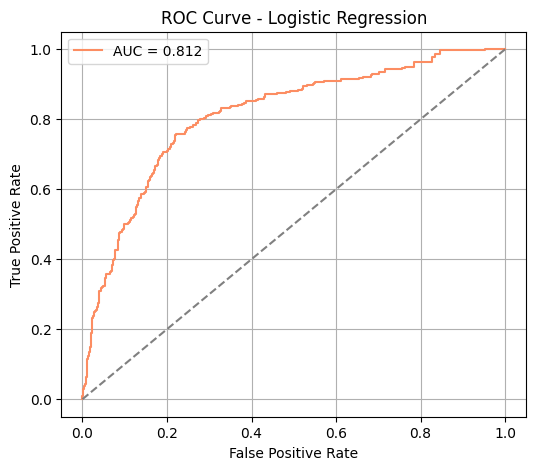

In [11]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {auc_lr:.3f}', color='#FC8D62')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)

The ROC curve confirms that the model has a reasonable ability to distinguish between Low and High quality wines, with an AUC above 0.80.

However, while ROC AUC reflects good overall discrimination, it does not fully capture the business impact of prediction errors.

While these results are consistent with the business objective, the trade-off highlights potential limitations of a linear model.  More flexible models may be able to achieve a better balance between precision and recall, improving overall business performance.

### Random Forest

Random Forest is introduced as a more flexible alternative to Logistic Regression.

Unlike linear models, Random Forest can capture non-linear patterns and complex interactions between variables, which may be especially useful in a problem where wine quality is influenced by multiple correlated features.

Since tree-based models are not sensitive to feature scale, no standardization step is required in this case.

In [12]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

As in the previous model, hyperparameter tuning is applied using GridSearchCV with Stratified K-Fold cross-validation and precision is used as the optimization metric in order to reduce false positive predictions, which represent the highest cost in the business cost matrix.

In [14]:
# Hyperparameter grid
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__class_weight': ['balanced']
}

cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv_rf,
    scoring='precision',
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'model__class_weight': ['balanced'],
                         'model__max_depth': [None, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='precision')

In [26]:
cv_results_rf = grid_rf.cv_results_
best_index_rf = grid_rf.best_index_

fold_scores_rf = [
    cv_results_rf[f'split{i}_test_score'][best_index_rf]
    for i in range(cv_rf.get_n_splits())
]

print("Best params:", grid_rf.best_params_)
print("Fold scores:", [f"{score:.4f}" for score in fold_scores_rf])

print(f"Best CV Precision: {grid_rf.best_score_:.4f}")

print(f"Mean CV Precision: {cv_results_rf['mean_test_score'][grid_rf.best_index_]:.4f}")
print(f"Std CV Precision: {cv_results_rf['std_test_score'][grid_rf.best_index_]:.4f}")

Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Fold scores: ['0.8022', '0.7831', '0.7561', '0.7500', '0.7805']
Best CV Precision: 0.7744
Mean CV Precision: 0.7744
Std CV Precision: 0.0191


The best Random Forest configuration achieved a mean cross-validated precision of approximately 0.77, with low variability across folds.

This represents a substantial improvement over Logistic Regression, suggesting that the model is better able to control false positives while maintaining stable performance across training folds.

These results indicate that allowing for non-linear decision boundaries adds meaningful predictive value in this classification problem.

In [37]:
best_model_rf = grid_rf.best_estimator_

y_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]

threshold_rf = 0.55
y_pred_rf_mod = (y_proba_rf >= threshold_rf).astype(int)

acc_rf = accuracy_score(y_test, y_pred_rf_mod)
precision_rf = precision_score(y_test, y_pred_rf_mod)
cm_rf = confusion_matrix(y_test, y_pred_rf_mod)
report_rf = classification_report(y_test, y_pred_rf_mod, target_names=['Low', 'High'], digits=4)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Random Forest (threshold = {threshold_rf})")
print(f"Accuracy test: {acc_rf:.4f}")
print(f"ROC AUC: {auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}\n")
print("Classification report:")
print(report_rf)
print("Confusion matrix:")
print(cm_rf)

Random Forest (threshold = 0.55)
Accuracy test: 0.8872
ROC AUC: 0.9312
Precision: 0.9050

Classification report:
              precision    recall  f1-score   support

         Low     0.8846    0.9844    0.9318      1090
        High     0.9050    0.5364    0.6736       302

    accuracy                         0.8872      1392
   macro avg     0.8948    0.7604    0.8027      1392
weighted avg     0.8890    0.8872    0.8758      1392

Confusion matrix:
[[1073   17]
 [ 140  162]]


Random Forest delivers a clear improvement over Logistic Regression on the test set.

The model achieves substantially higher precision and ROC AUC, while also improving overall accuracy. This indicates a stronger ability to distinguish between Low and High quality wines and to make more reliable positive predictions.

With the threshold adjusted to 0.55, the model maintains high precision while preserving a reasonable level of recall for the High quality class. From a business perspective, this is a strong result: the number of costly false positives is kept very low, without sacrificing too many true positive cases.

At this stage, Random Forest appears to offer a better balance between predictive performance and business impact than the baseline model.

However, before drawing a final conclusion, it is still necessary to evaluate XGBoost and compare all models under the same cost-sensitive framework.

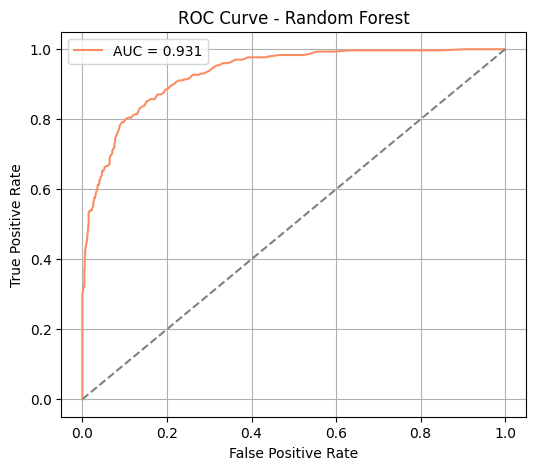

In [38]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {auc_rf:.3f}', color='#FC8D62')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)

The ROC curve confirms the strong discriminative ability of Random Forest, with an AUC above 0.93.

This indicates that the model is highly effective at ranking wines by quality across different threshold choices.

However, final model selection should rely on threshold-dependent metrics and profit, as business value depends on the cost of prediction errors.

### XGBoost

At last, XGBoost is evaluated as a more advanced ensemble model to determine whether boosting can further improve performance over Random Forest.

Compared with the previous models, XGBoost may provide a stronger balance between flexibility, predictive power, and control over classification errors, making it a strong candidate for the final comparison.

In [39]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ('model', XGBClassifier(random_state=42))
])

Hyperparameter tuning is applied to identify the XGBoost configuration that delivers the best precision under cross-validation.

As with the previous models, precision remains the optimization metric because the main business priority is to reduce false positive predictions.

In [40]:
# Hyperparameter grid
param_grid_xgb = {
    'model__n_estimators': [150, 200, 250],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}

cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=cv_xgb,
    scoring='precision',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      gamma=None,
                                                      grow_p...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.1, 0.2],
                         'model__max_depth': [3, 6, 9],
                         'model__n_estimators': [150, 200, 250],
                         'model__subsample': [0.8, 1.0]},
             scoring='precision')

In [41]:
cv_results_xgb = grid_xgb.cv_results_
best_index_xgb = grid_xgb.best_index_

fold_scores_xgb = [
    cv_results_xgb[f'split{i}_test_score'][best_index_xgb]
    for i in range(cv_xgb.get_n_splits())
]

print("Best params:", grid_xgb.best_params_)
print("Fold scores:", [f"{score:.4f}" for score in fold_scores_xgb])

print(f"Best CV Precision: {grid_xgb.best_score_:.4f}")

print(f"Mean CV Precision: {cv_results_xgb['mean_test_score'][grid_xgb.best_index_]:.4f}")
print(f"Std CV Precision: {cv_results_xgb['std_test_score'][grid_xgb.best_index_]:.4f}")

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__n_estimators': 250, 'model__subsample': 1.0}
Fold scores: ['0.7105', '0.7100', '0.6944', '0.7250', '0.7170']
Best CV Precision: 0.7114
Mean CV Precision: 0.7114
Std CV Precision: 0.0101


The best XGBoost configuration achieved a mean cross-validated precision of approximately 0.71, with very low variability across folds.

This indicates stable performance and strong control over false positives, although the cross-validated precision remains below the level achieved by Random Forest. At this stage, XGBoost appears competitive, but not clearly superior to the strongest model so far.

The tuned XGBoost model is then evaluated on the test set using an adjusted classification threshold of 0.60.

As in the previous models, the threshold is increased to make positive predictions more selective and better align model decisions with the business objective of limiting costly false positives.

In [42]:
best_model_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_model_xgb.predict(X_test)
y_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]


threshold = 0.6
y_pred_xgb_mod = (y_proba_xgb >= threshold).astype(int)

acc_xgb = accuracy_score(y_test, y_pred_xgb_mod)
precision_xgb = precision_score(y_test, y_pred_xgb_mod)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_mod)
report_xgb = classification_report(y_test, y_pred_xgb_mod, target_names=['Low', 'High'], digits=4)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"XGBoost (threshold = {threshold})")
print(f"Accuracy test: {acc_xgb:.4f}")
print(f"ROC AUC: {auc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}\n")
print("Classification report:")
print(report_xgb)
print("Confusion matrix:")
print(cm_xgb)

XGBoost (threshold = 0.6)
Accuracy test: 0.8779
ROC AUC: 0.9169
Precision: 0.7920

Classification report:
              precision    recall  f1-score   support

         Low     0.8945    0.9569    0.9246      1090
        High     0.7920    0.5927    0.6780       302

    accuracy                         0.8779      1392
   macro avg     0.8433    0.7748    0.8013      1392
weighted avg     0.8723    0.8779    0.8711      1392

Confusion matrix:
[[1043   47]
 [ 123  179]]


XGBoost delivers strong test performance, with high precision and a ROC AUC above 0.91.

Compared with Logistic Regression, the improvement is substantial. However, when compared with Random Forest, XGBoost does not appear to provide a clear advantage in the metrics most relevant to this project. In particular, Random Forest achieved higher precision, which is especially important given the business cost of false positives.

At this stage, XGBoost can be considered a strong candidate, but not the leading model before the final cost-sensitive comparison.

The ROC curve for XGBoost is included to keep the evaluation framework consistent across models.

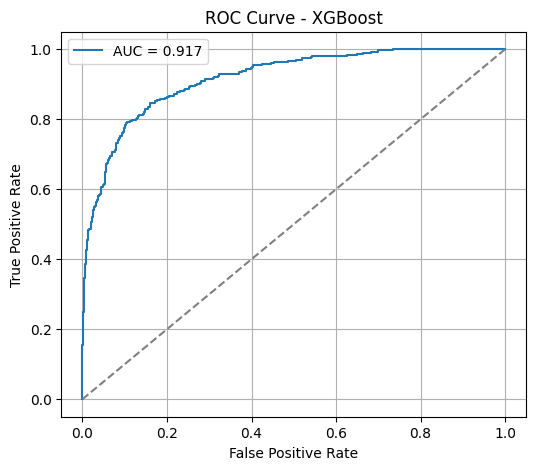

In [43]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f'AUC = {auc_xgb:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)

XGBoost shows strong overall class separation, although its performance remains slightly below Random Forest in terms of ROC AUC.

This reinforces the idea that XGBoost is a competitive model, but not clearly the strongest option based on predictive performance alone.

## Model Performance Comparison

To compare the models, their performance is evaluated using multiple classification metrics.

While several metrics are reported, special attention is given to precision and PR AUC, as they are more aligned with the business objective of minimizing costly false positive predictions.

This comparison provides a technical perspective on model performance before incorporating cost-sensitive evaluation.

In [47]:
from sklearn.metrics import recall_score, f1_score, average_precision_score, precision_recall_curve

models_dict = {
    'Logistic Regression': {
        'y_pred': y_pred_lr_mod,
        'y_proba': y_proba_lr,
        'name': 'LR'
    },
    'Random Forest': {
        'y_pred': y_pred_rf_mod,
        'y_proba': y_proba_rf,
        'name': 'RF'
    },
    'XGBoost': {
        'y_pred': y_pred_xgb_mod,
        'y_proba': y_proba_xgb,
        'name': 'XGB'
    }
}

# Compute evaluation metrics for each model
metrics_comparison = []

for model_name, model_data in models_dict.items():
    y_pred = model_data['y_pred']
    y_proba = model_data['y_proba']
    
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    metrics_comparison.append({
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'PR AUC': pr_auc,
        'ROC AUC': roc_auc
    })

df_metrics = pd.DataFrame(metrics_comparison)
df_metrics = df_metrics.set_index('Model')

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(df_metrics.round(4))
print()

MODEL PERFORMANCE COMPARISON
                     Precision  Recall  F1-Score  PR AUC  ROC AUC
Model                                                            
Logistic Regression     0.5651  0.5033    0.5324  0.5528   0.8123
Random Forest           0.9050  0.5364    0.6736  0.8287   0.9312
XGBoost                 0.7920  0.5927    0.6780  0.8050   0.9169



The results show a clear performance gap between Logistic Regression and the ensemble models.

Random Forest achieves the highest precision, indicating a strong ability to avoid false positive predictions. It also leads in PR AUC and ROC AUC, suggesting superior performance both in terms of positive class detection and overall class separation.

XGBoost performs significantly better than Logistic Regression and remains competitive, but it does not surpass Random Forest in the key metrics most relevant to this problem.

These results suggest that Random Forest is currently the strongest candidate from a predictive performance standpoint. However, final model selection should still consider the business cost structure to determine which model delivers the highest overall value.

## Cost-Sensitive Evaluation

To evaluate the models from a business perspective, confusion matrices are analyzed for each model.

These values allow us to quantify the number of true positives, false positives, true negatives, and false negatives, which are directly linked to the defined cost structure.

In [ ]:
cost_values = {
    'TP': 5,
    'TN': 1,
    'FP': -10,
    'FN': 0
}

profit_records = []

for model_name, model_data in models_dict.items():
    y_pred = model_data['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit = (
        tp * cost_values['TP'] +
        tn * cost_values['TN'] +
        fp * cost_values['FP'] +
        fn * cost_values['FN']
    )

    profit_records.append({
        'Model': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
    })

    print(f"{model_name}:")
    print(f"  TN: {tn}, FP: {fp}")
    print(f"  FN: {fn}, TP: {tp}")
    print()



Logistic Regression:
  TN: 973, FP: 117
  FN: 150, TP: 152

Random Forest:
  TN: 1073, FP: 17
  FN: 140, TP: 162

XGBoost:
  TN: 1043, FP: 47
  FN: 123, TP: 179



The confusion matrices reveal significant differences in how each model handles classification errors.

Random Forest produces a very low number of false positives compared to the other models, which is critical given the high cost associated with this type of error.

XGBoost achieves a higher number of true positives, but at the expense of more false positives. Logistic Regression, on the other hand, shows a weaker balance, with both higher false positives and lower true positives.

These differences highlight the importance of evaluating models not only through aggregated metrics, but also through their specific error distribution.

To determine the real business impact of each model, a cost-based evaluation is applied using the predefined cost matrix:

- True Positive: +5  
- True Negative: +1  
- False Positive: -10  
- False Negative: 0  

Using these values, the total profit generated by each model is calculated based on its confusion matrix.

In [50]:
df_profit = pd.DataFrame(profit_records).set_index('Model')

# Multiply each column by its cost value to see the real contribution
cost_multiplier = pd.Series({
    'TN': cost_values['TN'],
    'FP': cost_values['FP'],
    'FN': cost_values['FN'],
    'TP': cost_values['TP']
})
df_profit_contribution = df_profit[['TN', 'FP', 'FN', 'TP']].mul(cost_multiplier, axis=1)
df_profit_contribution['Profit'] = df_profit_contribution.sum(axis=1)

print('=' * 80)
print('PROFIT COMPARISON BY MODEL (COUNTS)')
print('=' * 80)
print(df_profit)
print()
print('=' * 80)
print('PROFIT COMPARISON BY MODEL (COST CONTRIBUTIONS)')
print('=' * 80)
print(df_profit_contribution)
print()

PROFIT COMPARISON BY MODEL (COUNTS)
                       TN   FP   FN   TP
Model                                   
Logistic Regression   973  117  150  152
Random Forest        1073   17  140  162
XGBoost              1043   47  123  179

PROFIT COMPARISON BY MODEL (COST CONTRIBUTIONS)
                       TN    FP  FN   TP  Profit
Model                                           
Logistic Regression   973 -1170   0  760     563
Random Forest        1073  -170   0  810    1713
XGBoost              1043  -470   0  895    1468



The profit-based evaluation clearly differentiates model performance from a business perspective.

Random Forest achieves the highest profit, significantly outperforming both Logistic Regression and XGBoost. This is primarily driven by its ability to minimize false positives, which carry the highest penalty in the cost structure.

Although XGBoost identifies more true positives, the additional false positives reduce its overall profitability. Logistic Regression performs the worst, as it fails to adequately control costly errors.

These results confirm that the model with the best predictive metrics is not necessarily the one that maximizes business value. In this case, Random Forest provides the best balance between prediction quality and cost efficiency.

This analysis highlights the importance of aligning model evaluation with business objectives. Optimizing traditional metrics alone would not have been sufficient to identify the most valuable model in this context.

## Final Conclusion

This project evaluated multiple classification models to predict wine quality, moving beyond traditional metrics to incorporate a cost-sensitive, business-oriented evaluation framework.

While Random Forest and XGBoost significantly outperformed Logistic Regression in predictive performance, the final model selection was based on profit rather than standard metrics alone. Random Forest emerged as the best model, achieving the highest profit by effectively minimizing false positives, which represent the most costly type of error in the defined cost structure.

This analysis demonstrates that the best-performing model from a technical perspective is not always the one that delivers the highest business value. Aligning model evaluation with real-world objectives is essential for making effective and impactful decisions in machine learning applications.